# Topomap PSD

Mappe topografiche a livello di canale per potenza assoluta, relativa e indici derivati. Le mappe HC/MS sono calcolate in due passaggi: prima la mediana sulle finestre di ogni soggetto, poi la media tra soggetti. In questo modo ogni soggetto ha lo stesso peso.

Per la potenza assoluta viene proposta una trasformazione `log10` esclusivamente per la visualizzazione; i dati canonici non vengono modificati.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from ipywidgets import Dropdown, IntSlider, interact

from eeg_ms.config import CANONICAL_DATA, CHANNELS_FILE, FIGURES
from eeg_ms.visualization.topomaps import (
    load_eeg_info,
    plot_condition_contrasts,
    plot_group_comparison,
    plot_topomap,
    subject_channel_map,
)

TOPOMAP_FIGURES = FIGURES / "topomaps"
TOPOMAP_FIGURES.mkdir(parents=True, exist_ok=True)

canonical = pd.read_parquet(CANONICAL_DATA)
info = load_eeg_info(CHANNELS_FILE)

print(f"Righe canoniche: {len(canonical):,}")
print(f"Soggetti: {canonical['subject_id'].nunique()}")
print(f"Canali nel montage: {len(info.ch_names)}")


Righe canoniche: 532,224
Soggetti: 32
Canali nel montage: 27


## Inventario PSD disponibile

In [11]:
psd_inventory = (
    canonical.loc[
        canonical["feature_family"].eq("psd"),
        ["measure", "band", "spatial_level"],
    ]
    .drop_duplicates()
    .sort_values(["measure", "band", "spatial_level"])
)
display(psd_inventory)


,measure,band,spatial_level
594,absolute_power,alpha,channel
1080,absolute_power,alpha,roi
1188,absolute_power,beta,channel
1674,absolute_power,beta,roi
1782,absolute_power,delta,channel
2268,absolute_power,delta,roi
2376,absolute_power,gamma,channel
2862,absolute_power,gamma,roi
2970,absolute_power,theta,channel
3456,absolute_power,theta,roi


## Potenza relativa alpha: HC, MS e differenza MS−HC

HC e MS condividono la stessa scala cromatica. La mappa della differenza usa una scala simmetrica centrata sullo zero.

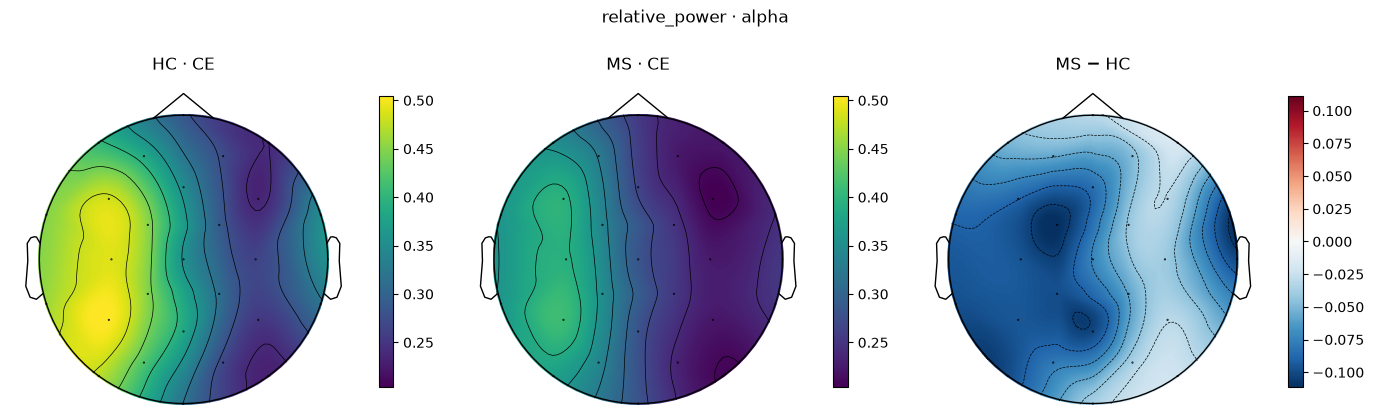

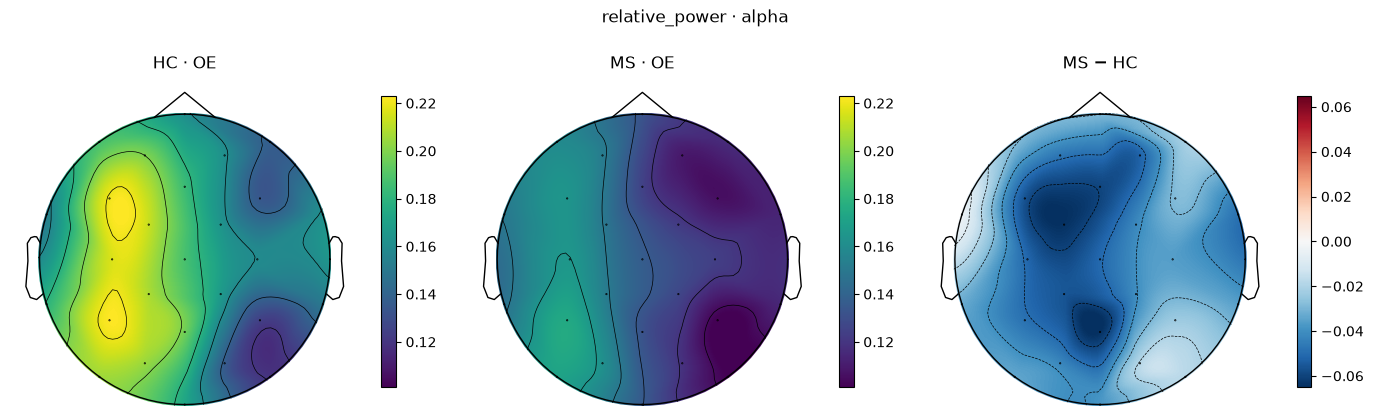

In [12]:
for condition in ["CE", "OE"]:
    figure = plot_group_comparison(
        canonical,
        info,
        condition=condition,
        measure="relative_power",
        band="alpha",
    )
    figure.savefig(
        TOPOMAP_FIGURES / f"relative_alpha_{condition}_hc_ms.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## Potenza assoluta alpha in scala log10

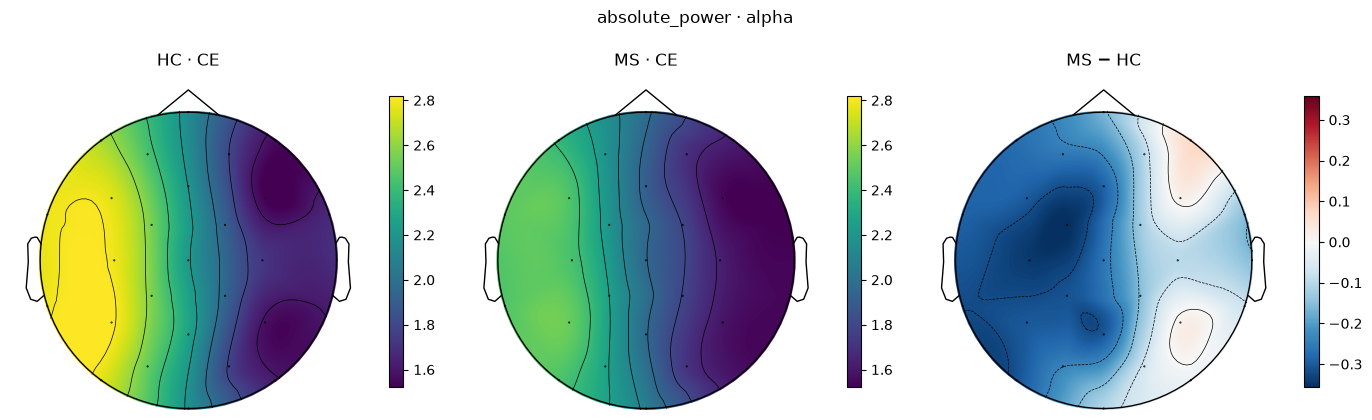

In [13]:
figure = plot_group_comparison(
    canonical,
    info,
    condition="CE",
    measure="absolute_power",
    band="alpha",
    transform="log10",
)
figure.savefig(
    TOPOMAP_FIGURES / "absolute_alpha_log10_CE_hc_ms.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## Differenza appaiata CE−OE

La sottrazione viene eseguita prima entro soggetto e solo successivamente mediata nel gruppo.

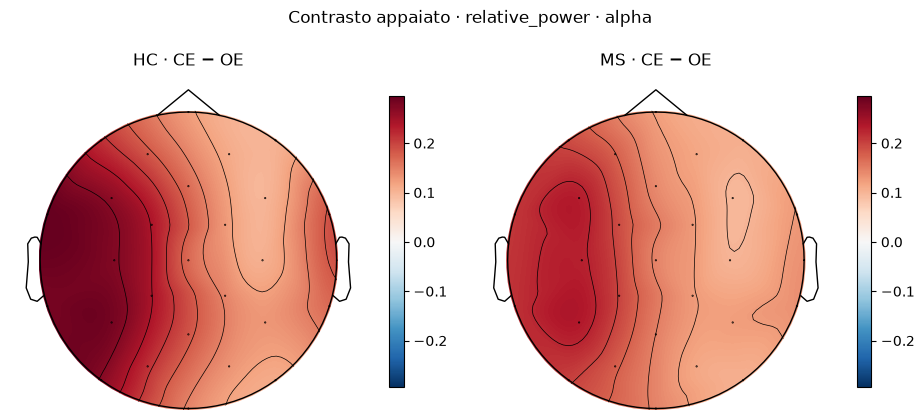

In [14]:
figure = plot_condition_contrasts(
    canonical,
    info,
    measure="relative_power",
    band="alpha",
)
figure.savefig(
    TOPOMAP_FIGURES / "relative_alpha_paired_CE_minus_OE.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## Rapporti theta/alpha, delta/alpha e SFR

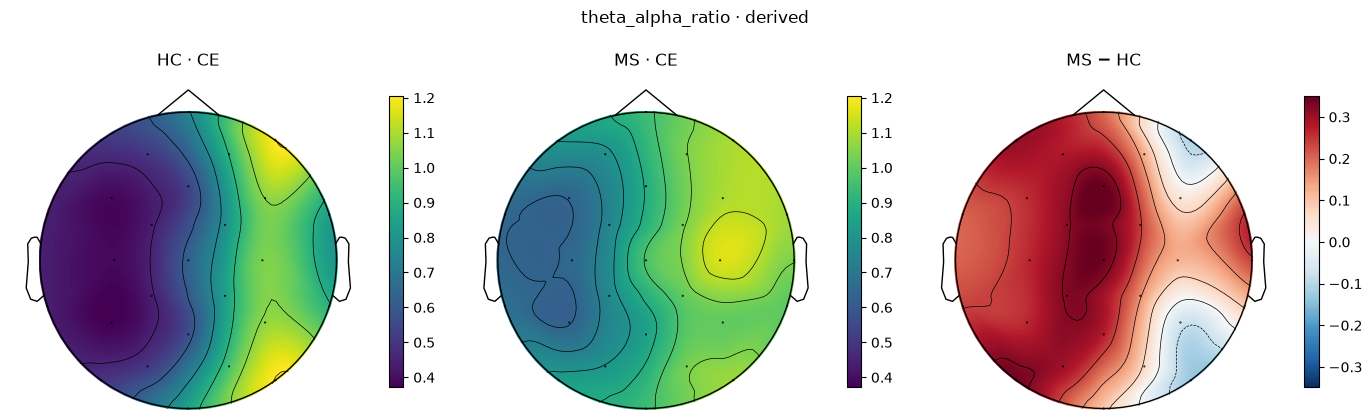

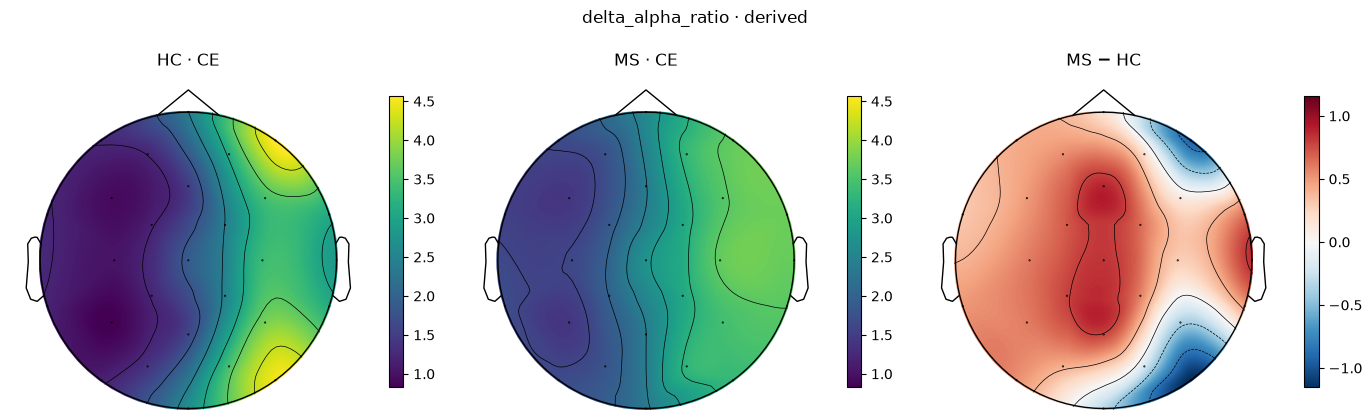

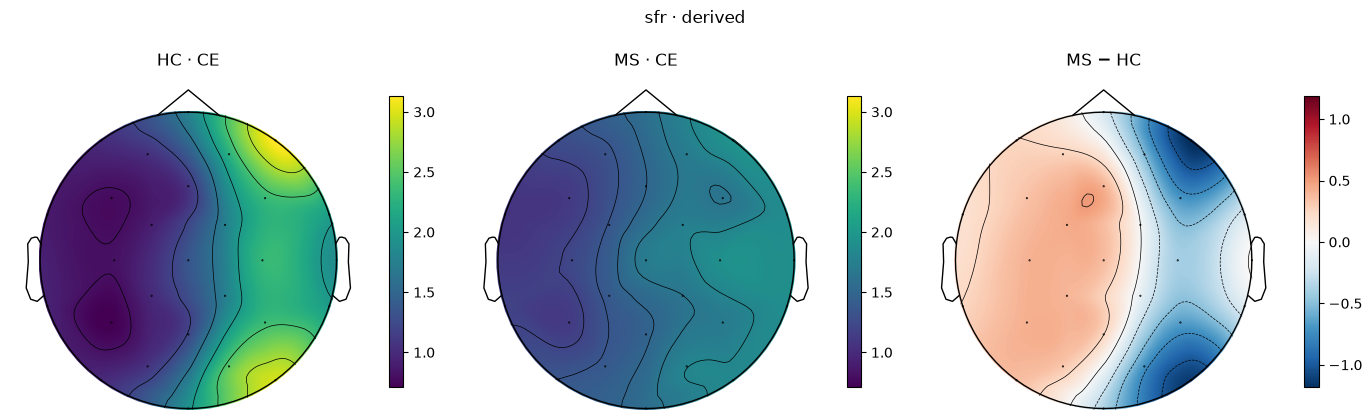

In [15]:
for measure in ["theta_alpha_ratio", "delta_alpha_ratio", "sfr"]:
    figure = plot_group_comparison(
        canonical,
        info,
        condition="CE",
        measure=measure,
        band="derived",
    )
    figure.savefig(
        TOPOMAP_FIGURES / f"{measure}_CE_hc_ms.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## Esplorazione interattiva di un soggetto

`window=0` mostra la mediana delle finestre; da 1 a 18 mostra la singola finestra.

In [16]:
subject_options = sorted(canonical["subject_id"].unique())

@interact(
    subject_id=Dropdown(options=subject_options, description="Soggetto"),
    condition=Dropdown(options=["CE", "OE"], description="Condizione"),
    measure=Dropdown(
        options=["relative_power", "absolute_power"],
        description="Misura",
    ),
    band=Dropdown(
        options=["delta", "theta", "alpha", "beta", "gamma"],
        value="alpha",
        description="Banda",
    ),
    window=IntSlider(min=0, max=18, value=0, description="Finestra"),
)
def explore_subject(subject_id, condition, measure, band, window):
    transform = "log10" if measure == "absolute_power" else None
    values = subject_channel_map(
        canonical,
        info,
        subject_id=subject_id,
        condition=condition,
        measure=measure,
        band=band,
        window=None if window == 0 else window,
        transform=transform,
    )
    title_window = "mediana finestre" if window == 0 else f"finestra {window}"
    figure, _ = plot_topomap(
        values,
        info,
        title=f"{subject_id} · {condition} · {measure} · {band} · {title_window}",
    )
    plt.show()


interactive(children=(Dropdown(description='Soggetto', options=('hc_01', 'hc_02', 'hc_03', 'hc_04', 'hc_05', '…

## Nota interpretativa

L'interpolazione tra elettrodi serve a rendere leggibile la distribuzione spaziale, ma non aggiunge nuova risoluzione anatomica. Le mappe rappresentano feature EEG sui 27 sensori, non attività corticale localizzata.